# Lab 1 — Section 3.3: Pillow (PIL)
Pillow is the easiest way to open, look at, and save images in Python.  
Think of it like a simple photo editor you control with code.

## Open and look at the image
`Image.open()` loads the file.  
In Jupyter, just typing the variable name at the end of a cell shows the image inline — no extra code needed.

Size (W x H): (512, 512)
Mode: RGBA


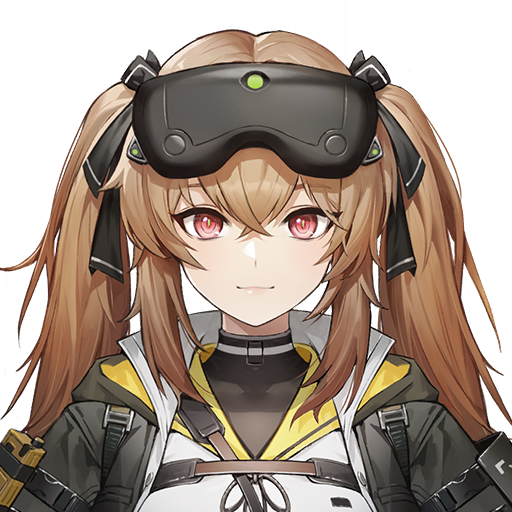

In [ ]:
from PIL import Image
import os

os.makedirs('../outputs', exist_ok=True)  # make sure outputs folder exists

img = Image.open('../data/sample_image.png')

# size = (width, height), mode = color type e.g. 'RGB'
print('Size (W x H):', img.size)
print('Mode:', img.mode)

img  # this line displays the image right here in the notebook

## Convert to grayscale
`convert('L')` removes color — each pixel becomes a single brightness value (0 = black, 255 = white).  
The `'L'` stands for **Luminance**.

Grayscale mode: L


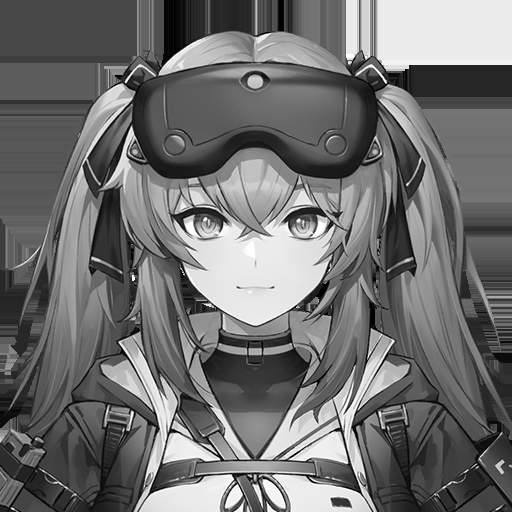

In [ ]:
gray = img.convert('L')
gray.save('../outputs/sample_image_gray_pillow.png')

print('Grayscale mode:', gray.mode)  # should print 'L' now, not 'RGB'

gray

## Threshold — turning the image black & white
A threshold picks a cutoff brightness.  
Every pixel **above** the cutoff → white (255).  
Every pixel **below** → black (0).  
We start with the grayscale image because you can only threshold single-channel images.

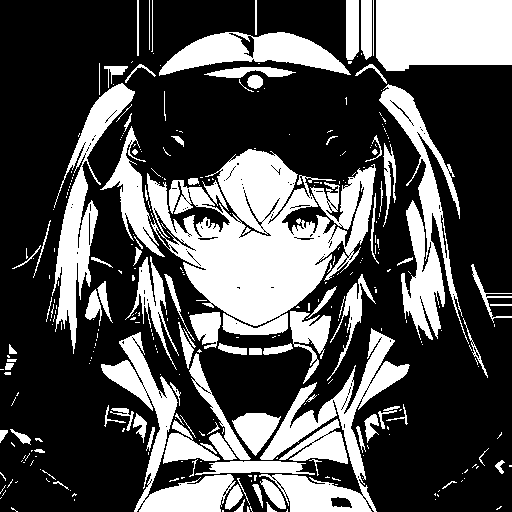

In [ ]:
threshold = 128  # middle of 0-255 range

# .point() applies a function to every pixel value
# p is the current pixel value, the lambda decides what to return
img_thresholded = gray.point(lambda p: 255 if p > threshold else 0)

img_thresholded.save('../outputs/sample_image_threshold_128.png')
img_thresholded

**What happened?**  
The image now only has two colors — pure black and pure white. All the detail in between is gone. This is useful for detecting edges or separating objects from backgrounds.

---
## 🔬 Extra things I tried

### What happens if I change the threshold value?

Low threshold (50):


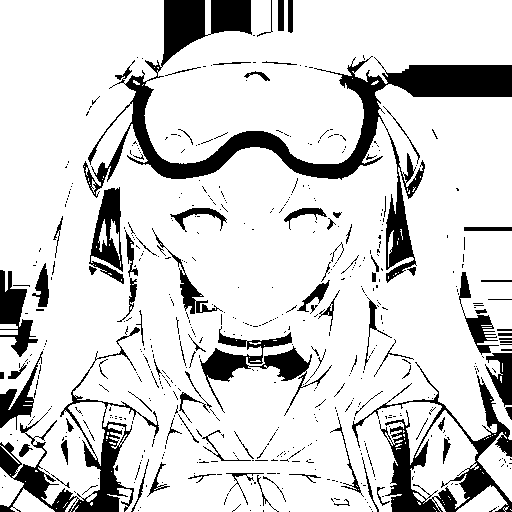

High threshold (200):


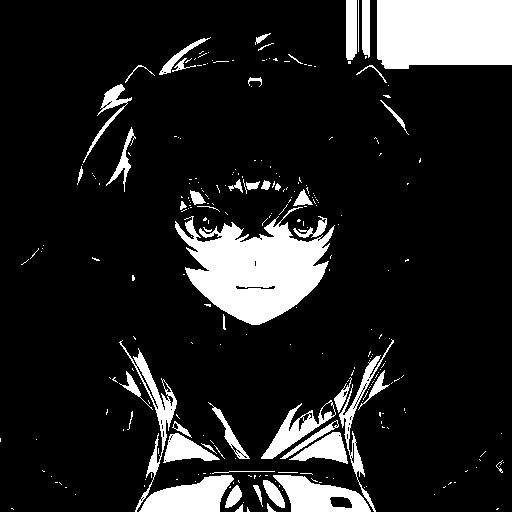

In [6]:
# low threshold → most pixels become white (bright result)
low = gray.point(lambda p: 255 if p > 50 else 0)

# high threshold → most pixels become black (dark result)
high = gray.point(lambda p: 255 if p > 200 else 0)

print('Low threshold (50):')
display(low)

print('High threshold (200):')
display(high)

A **low threshold** keeps most pixels white because almost everything is "bright enough".  
A **high threshold** keeps almost nothing — only the very brightest areas survive.

### Can I see the pixel values as numbers?

In [7]:
import numpy as np

arr = np.array(gray)  # convert the image to a numpy matrix
print('Shape:', arr.shape)        # (height, width) — no color channel for grayscale
print('Top-left 5x5 pixels:')
print(arr[:5, :5])                # slice the first 5 rows and 5 columns
print('Min pixel:', arr.min(), '| Max pixel:', arr.max())

Shape: (512, 512)
Top-left 5x5 pixels:
[[71 71 71 71 71]
 [71 71 71 71 71]
 [71 71 71 71 71]
 [71 71 71 71 71]
 [71 71 71 71 71]]
Min pixel: 0 | Max pixel: 255


### What does the RGB image look like as numbers?

In [8]:
arr_rgb = np.array(img)  # color image
print('Shape:', arr_rgb.shape)   # (height, width, 3) — 3 channels: Red, Green, Blue
print('Pixel at (0,0) — (R, G, B):', arr_rgb[0, 0])

Shape: (512, 512, 4)
Pixel at (0,0) — (R, G, B): [74 70 68  0]


### What if I invert the image?

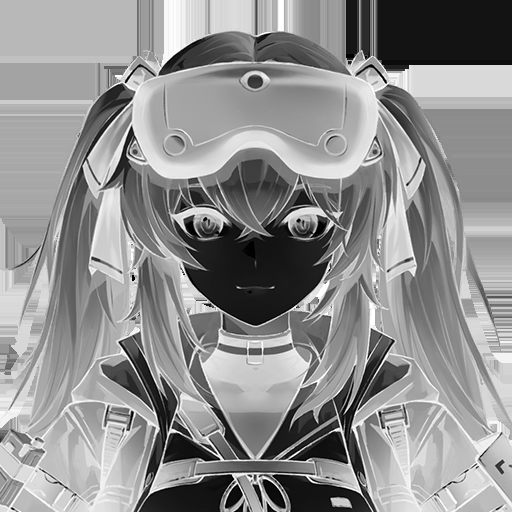

In [ ]:
from PIL import ImageOps

inverted = ImageOps.invert(gray)  # flips every pixel: 0 → 255, 255 → 0
inverted.save('../outputs/sample_image_inverted.png')
inverted

Dark areas become bright, bright areas become dark — like a photo negative.